**Mô hình sử dụng:** LightGBM  
**Input:** `train_missing_handled.csv`, `test_missing_handled.csv`  
**Output:** `train_fe.csv`, `test_fe.csv`


# Load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MultiLabelBinarizer
SAGE = '#9DC183'

train = pd.read_csv("../data/processed/train_missing_handled.csv")
test = pd.read_csv("../data/processed/test_missing_handled.csv")

train.head()

# Xử lý outliers

LightGBM là tree-based model nên **miễn dịch với hầu hết outlier** — cây quyết định

split theo ngưỡng chứ không tính khoảng cách hay tổng bình phương.

-> Vì vậy sau khi EDA thì cột runtime do có các giá trị lỗi nên sẽ Winsorize cột runtime.

Runtime trước winsorize:
count    3493.00
mean       83.70
std        44.93
min         1.00
25%        71.00
50%        95.00
75%       108.00
max       564.00
Name: runtime, dtype: float64

Giá trị bất thường (> 240 phút): 9 phim


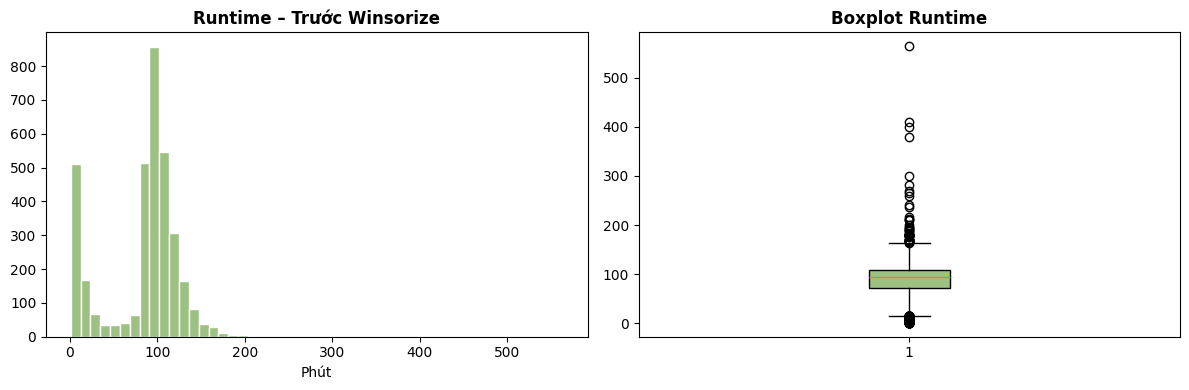

In [ ]:
# Kiểm tra runtime trước khi xử lý
print("Runtime trước winsorize:")
print(train['runtime'].describe().round(2))
print(f"\nGiá trị bất thường (> 240 phút): {(train['runtime'] > 240).sum()} phim")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['runtime'], bins=50, color=SAGE, edgecolor='white')
axes[0].set_title('Runtime – Trước Winsorize', fontweight='bold')
axes[0].set_xlabel('Phút')
axes[1].boxplot(train['runtime'], patch_artist=True,
                boxprops=dict(facecolor=SAGE))
axes[1].set_title('Boxplot Runtime', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Winsorize runtime – tính ngưỡng chỉ từ train, áp dụng cho cả test
Q1  = train['runtime'].quantile(0.25)
Q3  = train['runtime'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR   # → 15.5 phút
upper_bound = Q3 + 1.5 * IQR   # → 163.5 phút

print(f"Ngưỡng winsorize: [{lower_bound:.1f}, {upper_bound:.1f}] phút")
print(f"Số phim bị clip: {((train['runtime'] < lower_bound) | (train['runtime'] > upper_bound)).sum()}")

# Clip: dùng ngưỡng từ train để áp lên test (tránh data leakage)
train['runtime'] = train['runtime'].clip(lower=lower_bound, upper=upper_bound)
test['runtime']  = test['runtime'].clip(lower=lower_bound, upper=upper_bound)

print("\nRuntime sau winsorize:")
print(train['runtime'].describe().round(2))

Ngưỡng winsorize: [15.5, 163.5] phút
Số phim bị clip: 632

Runtime sau winsorize:
count    3493.00
mean       84.47
std        39.64
min        15.50
25%        71.00
50%        95.00
75%       108.00
max       163.50
Name: runtime, dtype: float64


# Feature Engineering

## Release_date

Trích xuất 3 features từ `release_date`:
- **`release_year`** — xu hướng theo thời gian
- **`release_month`** — theo mùa
- **`is_weekend`** — phim ra mắt cuối tuần (thứ 6–CN) có xu hướng doanh thu cao hơn


In [ ]:
for df in [train, test]:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

    df['release_year']  = df['release_date'].dt.year
    df['release_month'] = df['release_date'].dt.month

    # dayofweek: 0=Thứ 2, ..., 4=Thứ 6, 5=Thứ 7, 6=CN
    df['is_weekend'] = df['release_date'].dt.dayofweek.isin([4, 5, 6]).astype(int)

print("=== Train ===")
print(train[['release_date','release_year','release_month','is_weekend']].head(8))

print("\nPhân phối is_weekend (train):")
print(train['is_weekend'].value_counts().rename(index={0:'Ngày thường', 1:'Cuối tuần'}))

print("\nPhân phối release_year (train):")
print(train['release_year'].value_counts().sort_index())


=== Train ===
  release_date  release_year  release_month  is_weekend
0   2024-09-18          2024              9           0
1   2025-01-17          2025              1           1
2   2025-08-29          2025              8           1
3   2025-11-07          2025             11           1
4   2022-05-13          2022              5           1
5   2025-05-02          2025              5           1
6   2024-05-07          2024              5           0
7   2022-04-06          2022              4           0

Phân phối is_weekend (train):
is_weekend
Cuối tuần      2059
Ngày thường    1434
Name: count, dtype: int64

Phân phối release_year (train):
release_year
2020    387
2021    522
2022    577
2023    629
2024    673
2025    677
2026     28
Name: count, dtype: int64


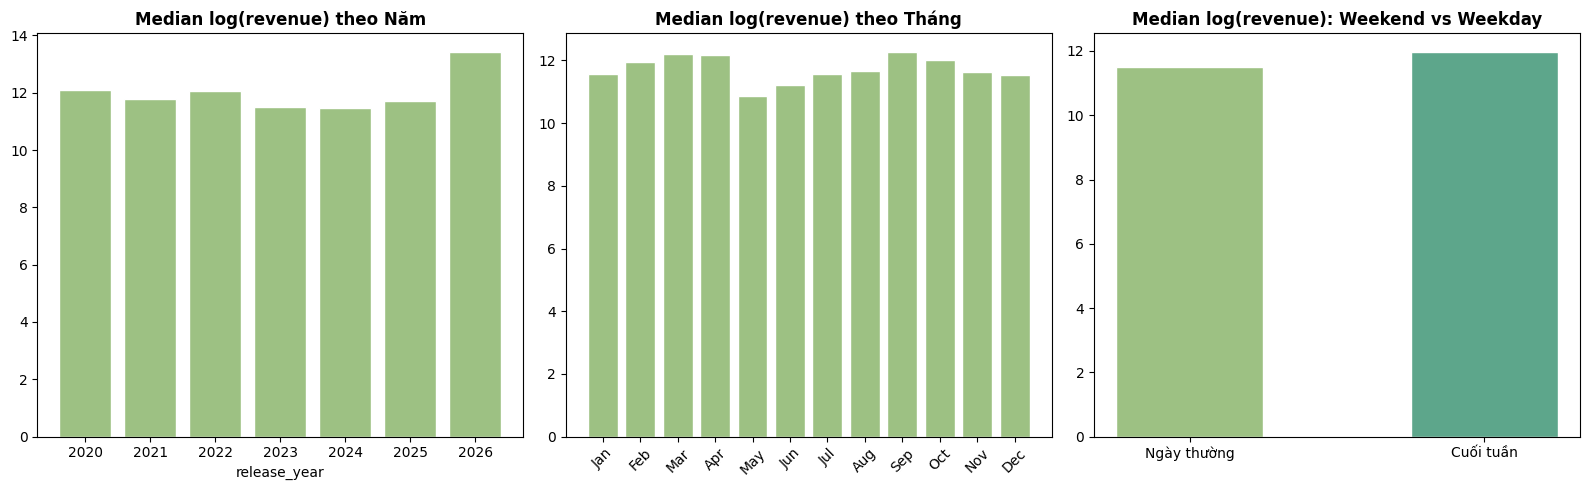

In [ ]:
# Kiểm tra nhanh: median revenue theo từng feature mới
df_check = train.dropna(subset=['revenue'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# release_year
year_rev = df_check.groupby('release_year')['revenue'].median()
axes[0].bar(year_rev.index.astype(int), np.log1p(year_rev.values), color=SAGE, edgecolor='white')
axes[0].set_title('Median log(revenue) theo Năm', fontweight='bold')
axes[0].set_xlabel('release_year')

# release_month
month_rev = df_check.groupby('release_month')['revenue'].median()
axes[1].bar(month_rev.index.astype(int), np.log1p(month_rev.values), color=SAGE, edgecolor='white')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[1].set_title('Median log(revenue) theo Tháng', fontweight='bold')

# is_weekend
wk_rev = df_check.groupby('is_weekend')['revenue'].median()
axes[2].bar(['Ngày thường', 'Cuối tuần'], np.log1p(wk_rev.values),
            color=[SAGE, '#5DA68B'], edgecolor='white', width=0.5)
axes[2].set_title('Median log(revenue): Weekend vs Weekday', fontweight='bold')

plt.tight_layout()
plt.show()


- Do cột `release_month` là Cyclical Features, một vòng lặp tuần hoàn. Nên khi chỉ để nguyên các tháng từ 1 đến 12 model thì nó không hiểu được điều này. Đặc biệt là mốc như tháng 12 - tháng 1, nó sẽ hiểu sai khoảng cách (11 đơn vị, trong khi 2 tháng này chỉ cách nhau 1 tháng).

- Để giúp model học tốt hơn thì ta sẽ dùng Cyclical Encoding cho cột `release_month`.
- `release_year`: là giá trị liên tục có thứ tự nên không xử lý gì thêm.
- `is_weekend`: đã được binary -> không xử lý thêm.

In [ ]:
# Cả 2 cột sin + cos phải được tạo trên CẢ 2 tập
for df in [train, test]:
    df['month_sin'] = np.sin(2 * np.pi * df['release_month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['release_month'] / 12)
    df.drop(columns=['release_month'], inplace=True)

## Genres (Multi-Label Binarization)

`genres` là cột multi-label (một phim có nhiều thể loại, ngăn cách bởi `|`).  
Dùng `MultiLabelBinarizer` của sklearn để tạo cột binary cho từng thể loại.

In [ ]:
# Tách genres thành list, bỏ giá trị 'Unknown'
train['genres_list'] = train['genres'].apply(
    lambda x: [g.strip() for g in x.split('|') if g.strip() != 'Unknown']
    if pd.notna(x) else []
)
test['genres_list'] = test['genres'].apply(
    lambda x: [g.strip() for g in x.split('|') if g.strip() != 'Unknown']
    if pd.notna(x) else []
)

print("Sample genres_list (train):")
print(train['genres_list'].head(5).tolist())

Sample genres_list (train):
[[], ['Crime', 'Drama', 'Thriller'], ['Action', 'Comedy', 'Horror'], ['Biography', 'Drama', 'History'], ['War', 'Action']]


In [ ]:
# Fit MultiLabelBinarizer chỉ trên train
mlb = MultiLabelBinarizer()
mlb.fit(train['genres_list'])

print(f"Tổng số thể loại: {len(mlb.classes_)}")
print("Danh sách thể loại:", mlb.classes_.tolist())

Tổng số thể loại: 23
Danh sách thể loại: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Romance', 'Science Fiction', 'Sport', 'TV Movie', 'Thriller', 'War', 'Western']


In [ ]:
# Tạo tên cột chuẩn: genre_action, genre_science_fiction, ...
genre_col_names = [f"genre_{g.lower().replace(' ', '_')}" for g in mlb.classes_]

# Transform train và test
genre_train_df = pd.DataFrame(
    mlb.transform(train['genres_list']),
    columns=genre_col_names,
    index=train.index
)
genre_test_df = pd.DataFrame(
    mlb.transform(test['genres_list']),
    columns=genre_col_names,
    index=test.index
)

# Ghép vào dataframe chính
train = pd.concat([train, genre_train_df], axis=1)
test  = pd.concat([test,  genre_test_df],  axis=1)

print(f"Đã thêm {len(genre_col_names)} cột genre:")
print(genre_col_names)
print()
# Tần suất từng genre trong train
print("Tần suất genre (train):")
print(train[genre_col_names].sum().sort_values(ascending=False).to_string())


Đã thêm 23 cột genre:
['genre_action', 'genre_adventure', 'genre_animation', 'genre_biography', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_history', 'genre_horror', 'genre_music', 'genre_musical', 'genre_mystery', 'genre_news', 'genre_romance', 'genre_science_fiction', 'genre_sport', 'genre_tv_movie', 'genre_thriller', 'genre_war', 'genre_western']

Tần suất genre (train):
genre_drama              1594
genre_comedy              915
genre_horror              682
genre_thriller            682
genre_action              604
genre_adventure           377
genre_documentary         370
genre_mystery             366
genre_crime               344
genre_romance             295
genre_biography           208
genre_science_fiction     201
genre_fantasy             195
genre_animation           192
genre_history             165
genre_family              154
genre_music               146
genre_war                  60
genre_sport         

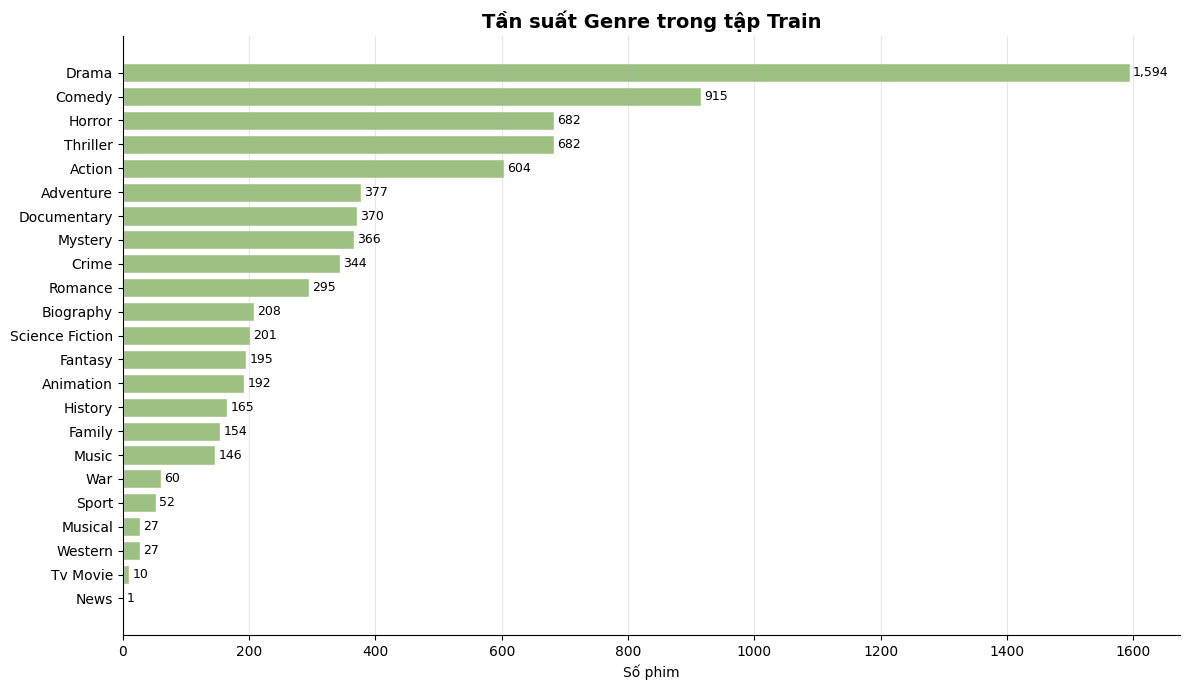

In [ ]:
# Visualize tần suất genre
genre_counts = train[genre_col_names].sum().sort_values(ascending=False)
clean_names  = [c.replace('genre_','').replace('_',' ').title() for c in genre_counts.index]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(clean_names[::-1], genre_counts.values[::-1], color=SAGE, edgecolor='white')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 5, bar.get_y() + bar.get_height()/2,
            f'{int(w):,}', va='center', fontsize=9)
ax.set_title('Tần suất Genre trong tập Train', fontsize=14, fontweight='bold')
ax.set_xlabel('Số phim')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## Director: Target Encoding + Smoothing

### Vấn đề với Target Encoding đơn giản
Nếu chỉ dùng `director → mean(revenue)` tính trên toàn bộ train rồi map vào:
- **Data leakage**: mỗi sample dùng chính revenue của mình để tạo feature
- **Overfit với đạo diễn ít phim**: đạo diễn có 1 phim → encoded = chính revenue phim đó

### Giải pháp: Smoothing (James-Stein style)
$$\text{encoded} = \frac{n \cdot \mu_{director} + k \cdot \mu_{global}}{n + k}$$

- $n$ = số phim của đạo diễn trong train  
- $\mu_{director}$ = log mean revenue của đạo diễn  
- $\mu_{global}$ = log mean revenue toàn bộ train  
- $k$ = **smoothing factor** (= 10): đạo diễn có ít hơn $k$ phim thì bị kéo về global mean

→ Đạo diễn nhiều phim: tin tưởng giá trị riêng  
→ Đạo diễn ít phim / không có trong train: fallback về global mean


In [ ]:
# Tính global mean trên log-scale (vì revenue lệch phải rất mạnh)
global_mean_log = np.log1p(train['revenue']).mean()
print(f"Global mean log(revenue): {global_mean_log:.4f}")
print(f"Tương đương revenue: ${np.expm1(global_mean_log):,.0f}")


Global mean log(revenue): 11.0608
Tương đương revenue: $63,624


In [ ]:
# Tính thống kê theo đạo diễn từ tập TRAIN
director_stats = (
    train.groupby('director')['revenue']
    .agg(count='count', mean_revenue='mean')
    .reset_index()
)
director_stats['log_mean'] = np.log1p(director_stats['mean_revenue'])

# Áp dụng công thức smoothing
k = 10  # smoothing factor

director_stats['director_encoded'] = (
    (director_stats['count'] * director_stats['log_mean'] + k * global_mean_log)
    / (director_stats['count'] + k)
)

# Xây dựng mapping dict
smoothed_map = director_stats.set_index('director')['director_encoded'].to_dict()

print("Ví dụ smoothing:")
print(director_stats.sort_values('count', ascending=False).head(10)
      [['director','count','log_mean','director_encoded']].to_string(index=False))


Ví dụ smoothing:
       director  count  log_mean  director_encoded
        Unknown     47 12.625996         12.351393
       Tom Bush     10  7.373751          9.217257
     Aldo Baruc      9  1.516347          6.539724
     Yen Ah Moi      8 12.100718         11.522965
 Moon Pelekanos      7  0.693147          6.791744
 Bruno Ferreira      6  8.044840          9.929792
  Santiago Cano      6  6.048554          9.181184
Haidar Shamseen      6  1.969441          7.651517
   Yuvraj Singh      6  8.081630          9.943588
Castille Landon      5 15.693814         12.605113


In [ ]:
# Map vào train và test
# Đạo diễn không có trong train → fillna bằng global_mean_log
train['director_encoded'] = train['director'].map(smoothed_map).fillna(global_mean_log)
test['director_encoded']  = test['director'].map(smoothed_map).fillna(global_mean_log)

print("director_encoded (train):")
print(train['director_encoded'].describe().round(4))

print(f"\nĐạo diễn trong test không có trong train: "
      f"{test['director'].map(smoothed_map).isnull().sum()} / {len(test)}")


director_encoded (train):
count    3493.0000
mean       11.0828
std         0.7730
min         6.5397
25%        10.7831
50%        11.1664
75%        11.4731
max        13.3651
Name: director_encoded, dtype: float64

Đạo diễn trong test không có trong train: 628 / 875


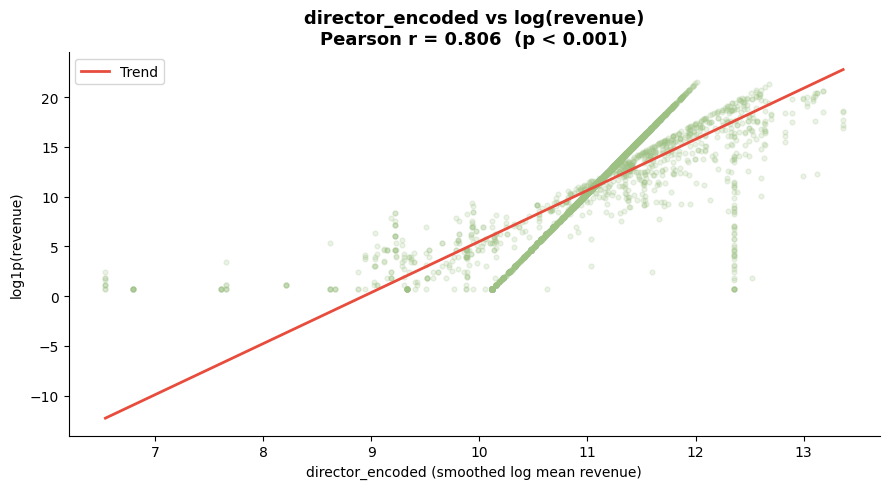

In [ ]:
# Visualize: so sánh director_encoded với log(revenue) thực tế
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(train['director_encoded'], np.log1p(train['revenue']),
           alpha=0.2, s=12, color=SAGE)

# Trend line
m, b = np.polyfit(train['director_encoded'], np.log1p(train['revenue']), 1)
x_line = np.linspace(train['director_encoded'].min(), train['director_encoded'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#e74c3c', linewidth=2, label='Trend')

from scipy.stats import pearsonr
r, p = pearsonr(train['director_encoded'], np.log1p(train['revenue']))
ax.set_title(f'director_encoded vs log(revenue)\nPearson r = {r:.3f}  (p < 0.001)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('director_encoded (smoothed log mean revenue)')
ax.set_ylabel('log1p(revenue)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# Dọn dẹp & Lưu kết quả


In [ ]:
# Drop các cột raw không còn cần thiết
cols_to_drop = ['release_date', 'genres', 'genres_list', 'director', 'budget']

train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
test  = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

print("=== Cột cuối cùng ===")
print(train.columns.tolist())
print(f"\nTrain shape: {train.shape}")
print(f"Test shape:  {test.shape}")

print("\n=== Missing values còn lại ===")
missing = train.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Không có missing")


=== Cột cuối cùng ===
['revenue', 'runtime', 'has_budget', 'director_missing', 'log_budget', 'release_year', 'is_weekend', 'month_sin', 'month_cos', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_biography', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_history', 'genre_horror', 'genre_music', 'genre_musical', 'genre_mystery', 'genre_news', 'genre_romance', 'genre_science_fiction', 'genre_sport', 'genre_tv_movie', 'genre_thriller', 'genre_war', 'genre_western', 'director_encoded']

Train shape: (3493, 33)
Test shape:  (875, 33)

=== Missing values còn lại ===
Không có missing


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3493 entries, 0 to 3492
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   revenue                3493 non-null   float64
 1   runtime                3493 non-null   float64
 2   has_budget             3493 non-null   int64  
 3   director_missing       3493 non-null   int64  
 4   log_budget             3493 non-null   float64
 5   release_year           3493 non-null   int32  
 6   is_weekend             3493 non-null   int64  
 7   month_sin              3493 non-null   float64
 8   month_cos              3493 non-null   float64
 9   genre_action           3493 non-null   int64  
 10  genre_adventure        3493 non-null   int64  
 11  genre_animation        3493 non-null   int64  
 12  genre_biography        3493 non-null   int64  
 13  genre_comedy           3493 non-null   int64  
 14  genre_crime            3493 non-null   int64  
 15  genr

In [ ]:
train.to_csv('../data/processed/train_fe.csv', index=False)
test.to_csv('../data/processed/test_fe.csv',   index=False)

print("  train_fe.csv: ", train.shape)
print("  test_fe.csv: ", test.shape)